# Anomaly detection

Jeet Purohit Malek

In [1]:
# Calculation and plottings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import product

#XAI imports
import eli5, shap
from lime.lime_tabular import LimeTabularExplainer
import shap

# For Models
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import IsolationForest
from sklearn.base import clone

# Metrics 
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    roc_auc_score, roc_curve
    ) 


In [2]:
df = pd.read_csv("loan_data.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (45000, 14)


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [3]:
print("Data types:")
print(df.dtypes)

Data types:
person_age                        float64
person_gender                      object
person_education                   object
person_income                     float64
person_emp_exp                      int64
person_home_ownership              object
loan_amnt                         float64
loan_intent                        object
loan_int_rate                     float64
loan_percent_income               float64
cb_person_cred_hist_length        float64
credit_score                        int64
previous_loan_defaults_on_file     object
loan_status                         int64
dtype: object


In [4]:
# Data distribution analysis
# GÖR DENNA BÄTTRE ELLER GRAFISKT
# KANSKE FLYTTA TILL SLUTET AV PREPROCCESSING STEGET
features = [
    'person_age', 'person_gender', 'person_education', 'person_income',
    'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_intent',
    'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
    'credit_score', 'previous_loan_defaults_on_file', 'loan_status'
]

categorical = [
    'person_gender', 'person_education', 'person_home_ownership',
    'loan_intent', 'previous_loan_defaults_on_file'
]
numerical = [f for f in features if f not in categorical]

for col in features:
    print(f"\n {col}")
    if col in numerical:
        print(f"  Min: {df[col].min()} | Max: {df[col].max()} | Mean: {df[col].mean():.2f} | Std: {df[col].std():.2f}")
    else:
        counts = df[col].value_counts()
        total = counts.sum()
        for val, cnt in counts.items():
            pct = cnt / total * 100
            print(f"  {val}: {cnt} ({pct:.1f}%)")


 person_age
  Min: 20.0 | Max: 144.0 | Mean: 27.76 | Std: 6.05

 person_gender
  male: 24841 (55.2%)
  female: 20159 (44.8%)

 person_education
  Bachelor: 13399 (29.8%)
  Associate: 12028 (26.7%)
  High School: 11972 (26.6%)
  Master: 6980 (15.5%)
  Doctorate: 621 (1.4%)

 person_income
  Min: 8000.0 | Max: 7200766.0 | Mean: 80319.05 | Std: 80422.50

 person_emp_exp
  Min: 0 | Max: 125 | Mean: 5.41 | Std: 6.06

 person_home_ownership
  RENT: 23443 (52.1%)
  MORTGAGE: 18489 (41.1%)
  OWN: 2951 (6.6%)
  OTHER: 117 (0.3%)

 loan_amnt
  Min: 500.0 | Max: 35000.0 | Mean: 9583.16 | Std: 6314.89

 loan_intent
  EDUCATION: 9153 (20.3%)
  MEDICAL: 8548 (19.0%)
  VENTURE: 7819 (17.4%)
  PERSONAL: 7552 (16.8%)
  DEBTCONSOLIDATION: 7145 (15.9%)
  HOMEIMPROVEMENT: 4783 (10.6%)

 loan_int_rate
  Min: 5.42 | Max: 20.0 | Mean: 11.01 | Std: 2.98

 loan_percent_income
  Min: 0.0 | Max: 0.66 | Mean: 0.14 | Std: 0.09

 cb_person_cred_hist_length
  Min: 2.0 | Max: 30.0 | Mean: 5.87 | Std: 3.88

 credit_s

# Data Preproccessing

* Remove unnessesary features: Person_Gender
* The the means for each gender are not far apart, but we think that it is a possibility that the model will learn some bias from the data we have.

In [5]:
mean_income_by_gender = df.groupby("person_gender")["person_income"].mean()
for gender, mean_income in mean_income_by_gender.items():
    print(f"{gender}: Mean income = {mean_income:.2f}")

female: Mean income = 79410.90
male: Mean income = 81056.03


* We want to change some of the categorical columns to Numerical values
* We also remove unnessesary features like "person_gender" beacuase this might not be needed

In [6]:
df = df.drop(columns=["person_gender"])

In [7]:
cat_cols = df.select_dtypes(include="object").columns.tolist()
print(f"Categorical columns: {cat_cols}\n")

Categorical columns: ['person_education', 'person_home_ownership', 'loan_intent', 'previous_loan_defaults_on_file']



In [8]:
label_encoders = {}
df_numerical = df.copy()

for col in cat_cols:
    le = LabelEncoder()
    df_numerical[col] = le.fit_transform(df_numerical[col])
    label_encoders[col] = le
    # print(f"{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

print(f"\nEncoded shape: {df_numerical.shape}")
df_numerical.iloc[13:20]


Encoded shape: (45000, 13)


,person_age,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
13,26.0,4,130713.0,0,3,35000.0,1,18.39,0.27,4.0,708,0,1
14,23.0,0,138998.0,0,3,35000.0,1,7.90,0.25,4.0,583,0,0
15,23.0,4,600891.0,5,0,30000.0,0,10.65,0.05,3.0,670,1,0
16,23.0,1,144943.0,0,3,35000.0,1,7.90,0.24,4.0,663,0,0
17,23.0,3,111369.0,0,3,35000.0,3,20.00,0.31,4.0,694,0,1
18,23.0,1,136628.0,0,3,35000.0,0,18.25,0.26,4.0,709,0,1
19,24.0,4,14283.0,1,0,1750.0,1,10.99,0.12,2.0,679,0,1


In [9]:
for col in cat_cols:
    le = LabelEncoder()
    le.fit(df[col])
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f"{col} mapping:")
    for k, v in mapping.items():
        print(f"  {k}: {v}")
    print()

person_education mapping:
  Associate: 0
  Bachelor: 1
  Doctorate: 2
  High School: 3
  Master: 4

person_home_ownership mapping:
  MORTGAGE: 0
  OTHER: 1
  OWN: 2
  RENT: 3

loan_intent mapping:
  DEBTCONSOLIDATION: 0
  EDUCATION: 1
  HOMEIMPROVEMENT: 2
  MEDICAL: 3
  PERSONAL: 4
  VENTURE: 5

previous_loan_defaults_on_file mapping:
  No: 0
  Yes: 1



    Feature dependencies and correlations

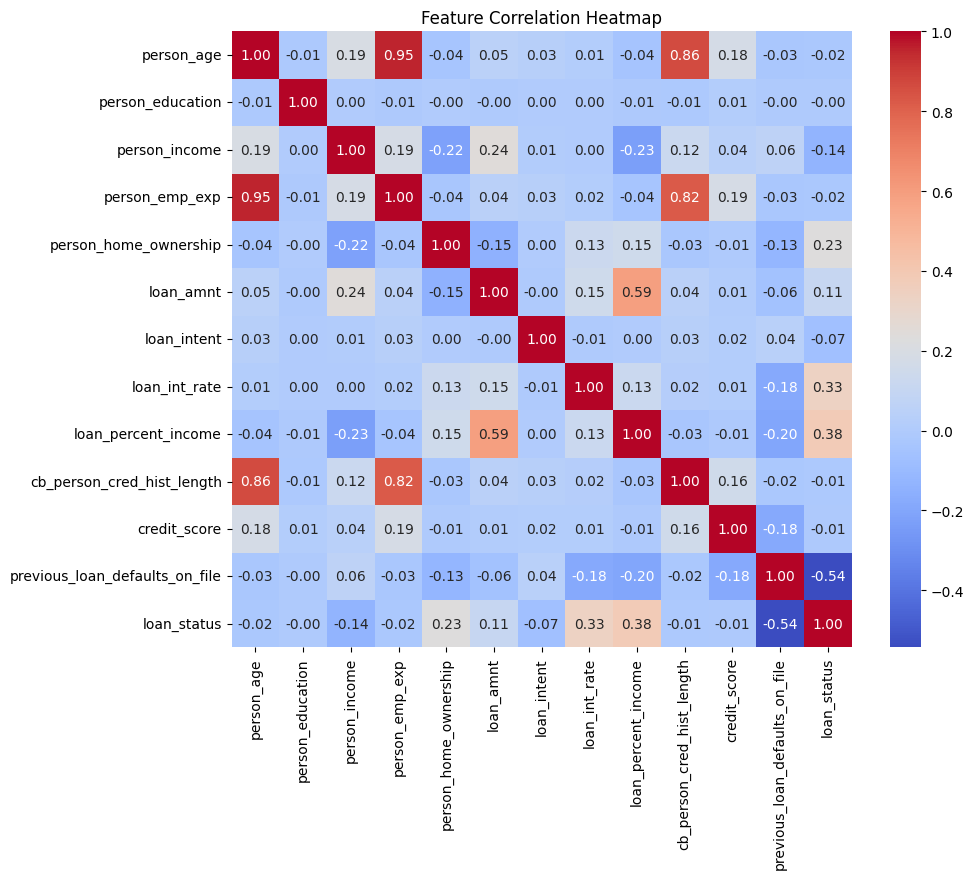

In [10]:
# Heatmap of feature correlations
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset (change path or DataFrame if needed)
df = pd.read_csv('loan_data.csv')

# Compute correlation matrix
corr = df_numerical.corr()

# Plot heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

# Missing values/incomplete samples

In [11]:
nulls = df_numerical.isnull().sum()
total_null = nulls.sum()
print("number of null", total_null)

number of null 0


# Outliers
* we se that there are only 7 people over 100 taking loans, we remove this beacause------------------- below cells we first caount all the outliers and then remove them
* 24 åpeople over income person
* 12 people over 50 year sof eperiance, you usially take pension at 65 years old
* we converted float to int in cb_person_cred_hist_length because we saw that there were no float values. 

In [12]:
# Count samples where person_age > 100

person_age_100 = (df_numerical['person_age'] >= 100).sum()
person_age_18 = (df_numerical['person_age'] <= 18).sum()
print(f"Number of samples with person_age more then 100: {person_age_100}")
print(f"Number of samples with person_age less then 18: {person_age_18}")



Number of samples with person_age more then 100: 7
Number of samples with person_age less then 18: 0


In [13]:
person_income_1M = (df_numerical['person_income'] > 1000000).sum()
print(f"Number of samples with person_income > 1M: {person_income_1M}")

Number of samples with person_income > 1M: 24


In [14]:
person_emp_exp_over_ = (df_numerical['person_emp_exp'] > 50).sum()
print(f"Number of samples with person_emp_exp > 50: {person_emp_exp_over_}")

Number of samples with person_emp_exp > 50: 12


In [15]:
# Check for float columns and show unique values for cb_person_cred_hist_length
# float_cols = df.select_dtypes(include='float')
# print("Float columns:", float_cols.columns.tolist())

# if 'cb_person_cred_hist_length' in df.columns:
#     print("Unique values in cb_person_cred_hist_length:")
print(sorted(df_numerical['cb_person_cred_hist_length'].unique()))

[np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(10.0), np.float64(11.0), np.float64(12.0), np.float64(13.0), np.float64(14.0), np.float64(15.0), np.float64(16.0), np.float64(17.0), np.float64(18.0), np.float64(19.0), np.float64(20.0), np.float64(21.0), np.float64(22.0), np.float64(23.0), np.float64(24.0), np.float64(25.0), np.float64(26.0), np.float64(27.0), np.float64(28.0), np.float64(29.0), np.float64(30.0)]


In [16]:
# Convert all values in cb_person_cred_hist_length to integers
print(df_numerical['cb_person_cred_hist_length'].head())
df_numerical['cb_person_cred_hist_length'] = df_numerical['cb_person_cred_hist_length'].astype(int)

print(df_numerical['cb_person_cred_hist_length'].head())

0    3.0
1    2.0
2    3.0
3    2.0
4    4.0
Name: cb_person_cred_hist_length, dtype: float64
0    3
1    2
2    3
3    2
4    4
Name: cb_person_cred_hist_length, dtype: int64


In [17]:
# print(f"Before cleaning: {df.shape[0]} rows")

# remove unrealistic ages (e.g. 100+)
df_numerical = df_numerical[df_numerical["person_age"] <= 100]

# remove extreme employment experience outliers
df_numerical = df_numerical[df_numerical["person_emp_exp"] <= 60]

print(f"After cleaning: {df.shape[0]} rows")
print(f"Removed {45000 - df.shape[0]} outlier rows")

After cleaning: 45000 rows
Removed 0 outlier rows


# Data preprocessing 
* splitting the data test aand shit

In [18]:
X = df_numerical.drop(columns=["loan_status"])
y = df_numerical["loan_status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)


# lin and not lin 

# evaulation and model tuning
- tuning 
    * use grid searchCV
    * first run we had alot of diffrent combination in param_grid, this took 4 minutes to run. second run we narrowed the parameter values around the "best fit" parameters. eg if we had max depth 20 in max depth first run. we then change the list so it checks the scond run 18, 20, 23 24, none.

    snotees, change paramets



In [19]:
print(len(X_train))

35992


# TIME TO RUN 3 mins.
    depends on PC stats 

In [20]:

# dt_model = DecisionTreeClassifier(random_state=42)
# skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
# scores = ['f1', 'precision', 'recall']

# # Model tuning, finding best parameters --------------------------------------------
# param_grid = {
#     'max_depth': [16, 18, 25, None],
#     'min_samples_split': [7, 10, 12, 20,],
#     'min_samples_leaf': [29, 32, 35, 38],
#     'class_weight': ["balanced", None],
#     'min_weight_fraction_leaf' : [0.0, 0.05],
#     'max_features' : ['sqrt', 'log2', None]
# }

# # !Note! change n_jobs in parameters below depending on how many cores you want to use.
# grid_search = GridSearchCV(estimator=dt_model, param_grid=param_grid, 
#                            cv=10, n_jobs=-1, verbose=2, scoring=scores, refit='f1') 


# grid_search.fit(X_train, y_train)
# tuned_dt = grid_search.best_estimator_ #here we set the best parameters on our model

# best_params = grid_search.best_params_ 
# print(f"Best parameters: ")
# for param, value in best_params.items():
#     print(f"{param}: {value}")

# #-----------------------------------------------------------------------------------------

# # Evaluation across 10 folds with the fine tuned model -----------------------------------
# cv_results = cross_validate(tuned_dt, X_train, y_train, cv=skf, scoring=scores,
#                             return_train_score=False)

# print("scores evaluation phase:\n")
# for metric in scores:
#     scores = cv_results[f"test_{metric}"]
#     print(f"{metric:>10s}:  mean={scores.mean():.4f}  std={scores.std():.4f}")

# #-----------------------------------------------------------------------------------------
# y_pred = tuned_dt.predict(X_test)

# real_f1   = f1_score(y_test, y_pred)
# real_prec = precision_score(y_test, y_pred)
# real_rec  = recall_score(y_test, y_pred)


# print(" scores y_eval vs y_test")

# print(f"F1:       {real_f1:.4f}")
# print(f"Precision:{real_prec:.4f}")
# print(f"Recall:   {real_rec:.4f}")


# copy of above cell
    the below cell is a copy of above, we have added the best parameters from above so that it is quicker to run. but above cell is the complete process with searchSV that we have used

In [21]:

dt_model = DecisionTreeClassifier(random_state=42)
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
dt_metrics = ['f1', 'precision', 'recall']

# Model tuning, finding best parameters --------------------------------------------
param_grid = {
    'max_depth': [18],
    'min_samples_split': [7],
    'min_samples_leaf': [35],
    'class_weight': [None],
    'min_weight_fraction_leaf' : [0.0],
    'max_features' : [None]
}

# !Note! change n_jobs in parameters below depending on how many cores you want to use.
grid_search = GridSearchCV(estimator=dt_model, param_grid=param_grid, 
                           cv=10, n_jobs=-1, verbose=2, scoring=dt_metrics, refit='f1') 

grid_search.fit(X_train, y_train)
tuned_dt = grid_search.best_estimator_ #here we set the best parameters on our model

best_params = grid_search.best_params_ 
print(f"Best parameters: ")
for param, value in best_params.items():
    print(f"{param}: {value}")

#-----------------------------------------------------------------------------------------

# Evaluation across 10 folds with the fine tuned model -----------------------------------
cv_results = cross_validate(tuned_dt, X_train, y_train, cv=skf, scoring=dt_metrics,
                            return_train_score=False)


print("scores evaluation phase:\n")
for metric in dt_metrics:
    dt_test_scores = cv_results[f"test_{metric}"]
    print(f"{metric:>10s}:  mean={dt_test_scores.mean():.4f}  std={dt_test_scores.std():.4f}")

#-----------------------------------------------------------------------------------------
y_pred = tuned_dt.predict(X_test)

real_f1   = f1_score(y_test, y_pred)
real_prec = precision_score(y_test, y_pred)
real_rec  = recall_score(y_test, y_pred)


print(" scores y_eval vs y_test")

print(f"F1:       {real_f1:.4f}")
print(f"Precision:{real_prec:.4f}")
print(f"Recall:   {real_rec:.4f}")


Fitting 10 folds for each of 1 candidates, totalling 10 fits
Best parameters: 
class_weight: None
max_depth: 18
max_features: None
min_samples_leaf: 35
min_samples_split: 7
min_weight_fraction_leaf: 0.0
scores evaluation phase:

        f1:  mean=0.8027  std=0.0131
 precision:  mean=0.8486  std=0.0209
    recall:  mean=0.7619  std=0.0160
 scores y_eval vs y_test
F1:       0.7978
Precision:0.8377
Recall:   0.7615


# test on unseen data
- this thest is made so we can se if our model perofms similar to above, not similar = overfitting or problem in data splitting

In [22]:
print(classification_report(y_test, y_pred, target_names=["Rejected", "Approved"]))


              precision    recall  f1-score   support

    Rejected       0.93      0.96      0.95      6998
    Approved       0.84      0.76      0.80      2000

    accuracy                           0.91      8998
   macro avg       0.89      0.86      0.87      8998
weighted avg       0.91      0.91      0.91      8998



# confusion metric
snacka om specificity

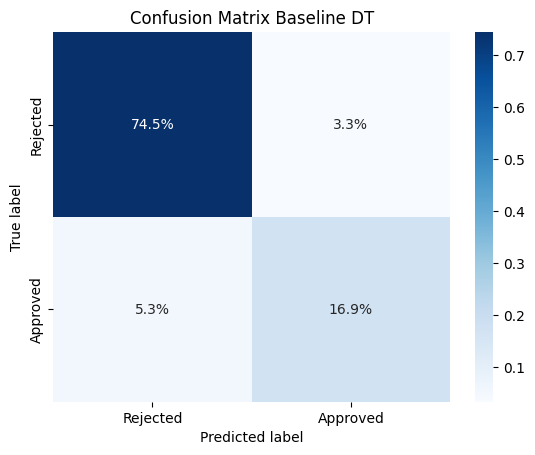

In [23]:

cm = confusion_matrix(y_test, y_pred)
cm_percent = cm / cm.sum() * 100  # Convert to percent of all samples

cf_norm = cm.astype('float') / cm.sum()

# 2. Create annotation text with '%'
labels = (np.asarray(["{0:.1f}%".format(value*100) 
                    for value in cf_norm.flatten()])).reshape(2,2)

# 3. Plot
sns.heatmap(cf_norm, annot=labels, fmt='', cmap='Blues', xticklabels=["Rejected", "Approved"], yticklabels=["Rejected", "Approved"])
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix Baseline DT")
plt.show()

In [24]:
# # specificity = TN / (TN + FP)
# cm_baseline = confusion_matrix(y_test, y_pred)
# test_spec = cm_baseline[0, 0] / (cm_baseline[0, 0] + cm_baseline[0, 1])

# print(f"  Specificity: {test_spec:.4f}")

# fig, ax = plt.subplots(figsize=(5, 4))
# ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["Rejected", "Approved"], cmap="Blues", ax=ax)
# ax.set_title("Confusion Matrix - Baseline")
# plt.tight_layout()
# plt.show()

# print tree


In [25]:
# print(f"Total rows: {df_numerical.shape[0]}")

# återkom om nedan och see om ni kan läsa av

In [26]:
# plt.figure(figsize=(250, 90))
# plot_tree(tuned_dt, feature_names=X_train.columns, class_names=['Not Approved', 'Approved'], filled=True, max_depth=10)
# plt.show()

# feature importance

Tree depth: 18
Number of leaves: 282

previous_loan_defaults_on_file    0.4138
loan_percent_income               0.1864
loan_int_rate                     0.1824
person_income                     0.0993
person_home_ownership             0.0509
loan_intent                       0.0303
credit_score                      0.0241
loan_amnt                         0.0042
person_emp_exp                    0.0036
cb_person_cred_hist_length        0.0023
person_education                  0.0016
person_age                        0.0011


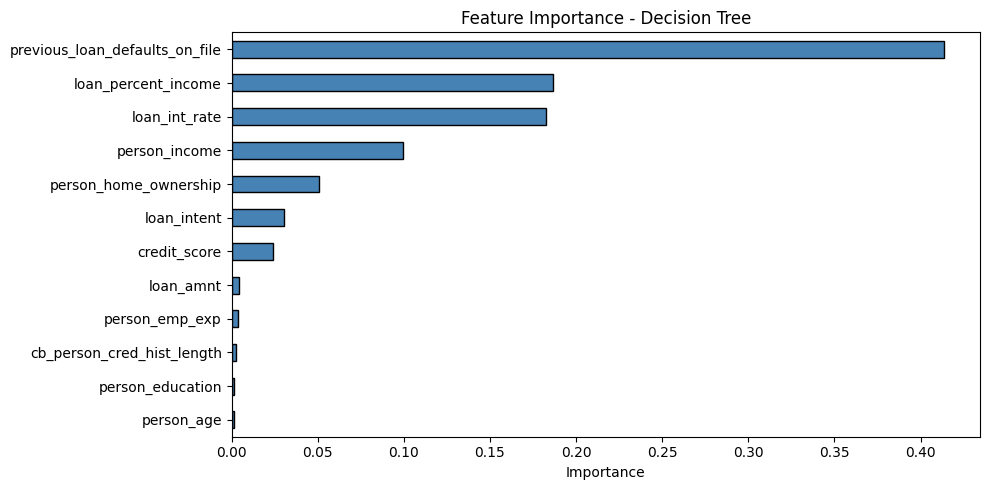

In [27]:
importances = pd.Series(tuned_dt.feature_importances_, index=X.columns).sort_values(ascending=False)

print(f"Tree depth: {tuned_dt.get_depth()}")
print(f"Number of leaves: {tuned_dt.get_n_leaves()}\n")
print(importances.round(4).to_string())

fig, ax = plt.subplots(figsize=(10, 5))
importances.plot.barh(ax=ax, color="steelblue", edgecolor="black")
ax.set_title("Feature Importance - Decision Tree")
ax.set_xlabel("Importance")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# tree explainer
    vet ej hur vi ska använda denna.

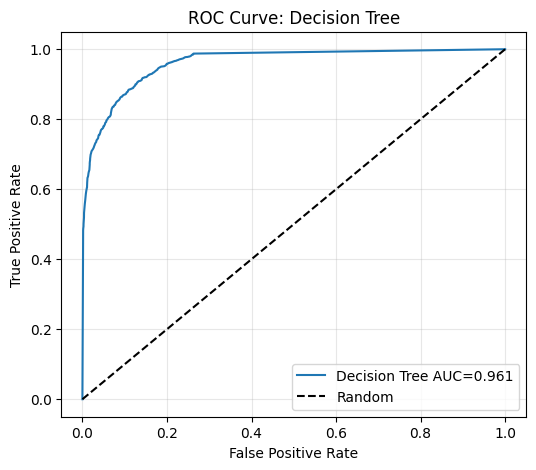

In [28]:

# 1. Get predicted probabilities for the positive class (Approved = 1)
y_proba = tuned_dt.predict_proba(X_test)[:, 1]

# 2. Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

# 3. Plot ROC curve
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"Decision Tree AUC={auc:.3f}")
plt.plot([0,1], [0,1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Decision Tree")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:

# ---------------??????????????????????--------------------

explainer = shap.TreeExplainer(tuned_dt)
shap_values = explainer.shap_values(X_test)
# shap_values



In [30]:
# Sample to test the tuned decision tree

# gör ett sample där vi har previous_loan_defaults_on_file" = 0: men allt annat är helt kaos,
# alla andra feature är som ett rejected sample.
sample = {
    "person_age": 25.0,
    "person_education": 3,
    "person_income": 12438.0,
    "person_emp_exp": 3,
    "person_home_ownership": 0,
    "loan_amnt": 5500.0,
    "loan_intent": 3,
    "loan_int_rate": 12.82,
    "loan_percent_income": 0.44,
    "cb_person_cred_hist_length": 3.0,
    "credit_score": 535,
    "previous_loan_defaults_on_file": 0,
}
# previous_loan_defaults_on_file    0.4138
# loan_percent_income               0.1864
# loan_int_rate                     0.1824
# person_income                     0.0993
# person_home_ownership             0.0509
# loan_intent                       0.0303
# credit_score                      0.0241

# 25.0	3	12438.0	3	0	5500.0	3	12.87	0.44	3.0	635	0 # approved
# 23.0	1	144943.0	0	3	35000.0	1	7.90	0.24	4.0	663	0  rejected

sample = pd.DataFrame([sample], columns=X_train.columns)

# Predict with tuned decision tree
pred_class = tuned_dt.predict(sample)[0]
pred_proba = tuned_dt.predict_proba(sample)[0, 1]

label = "Approved" if pred_class == 1 else "Rejected"
print(f"Decision Tree (tuned) prediction: {label} ({pred_class})")

Decision Tree (tuned) prediction: Approved (1)


In [31]:
# Correctly filter for approved loans WITH previous defaults
approved_with_defaults = df_numerical[
    (df_numerical['previous_loan_defaults_on_file'] == 1) & 
    (df_numerical['loan_status'] == 1)
]
# Display the filtered samples
print(f"Found {len(approved_with_defaults)} samples where a loan was approved despite a previous default.")
approved_with_defaults.head()

Found 0 samples where a loan was approved despite a previous default.


,person_age,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status


    varför gör jag detta?
    vi ser att det finns INGA FALL där du har loan of default och dina lån är approved. detta är stort problem. detta gör att decision tree blir jätte bias wtf detta gör att en approved blir direkt rejected om du har loan on default


In [32]:
# Create a cross-tabulation to see all combinations
combination_counts = pd.crosstab(
    df_numerical['previous_loan_defaults_on_file'],
    df_numerical['loan_status']
)

# Rename the index and columns for better readability
combination_counts.index = combination_counts.index.map({0: 'No Previous Default (0)', 1: 'Previous Default (1)'})
combination_counts.columns = combination_counts.columns.map({0: 'Loan Rejected (0)', 1: 'Loan Approved (1)'})


print("Breakdown of Loan Status vs. Previous Defaults:")
print(combination_counts)

Breakdown of Loan Status vs. Previous Defaults:
loan_status                     Loan Rejected (0)  Loan Approved (1)
previous_loan_defaults_on_file                                      
No Previous Default (0)                     12135              10000
Previous Default (1)                        22855                  0


In [33]:
# Get the underlying tree object
tree = tuned_dt.tree_
feature_names = X_train.columns

# Get the decision path for the sample
decision_path = tuned_dt.decision_path(sample).toarray()[0]
visited_nodes = [i for i, node in enumerate(decision_path) if node == 1]

print("Decision path for the sample:")
# Iterate over all nodes in the decision path
for i, node_id in enumerate(visited_nodes):
    # Skip the last node since it's the leaf (final prediction)
    if i == len(visited_nodes) - 1:
        class_prediction = tree.value[node_id].argmax()
        label = "Approved" if class_prediction == 1 else "Rejected"
        print(f"  -> Node {node_id} (Leaf): Final prediction is '{label}'")
        continue

    # Get split information from the tree object
    feature_index = tree.feature[node_id]
    feature_name = feature_names[feature_index]
    threshold = tree.threshold[node_id]
    sample_value = sample[feature_name].iloc[0]

    # Determine which child node was taken
    next_node_id = visited_nodes[i + 1]
    if next_node_id == tree.children_left[node_id]:
        print(f"  -> Node {node_id}: Split on '{feature_name}'. Sample value {sample_value:.2f} <= {threshold:.2f}.")
    else:
        print(f"  -> Node {node_id}: Split on '{feature_name}'. Sample value {sample_value:.2f} > {threshold:.2f}.")


Decision path for the sample:
  -> Node 0: Split on 'previous_loan_defaults_on_file'. Sample value 0.00 <= 0.50.
  -> Node 1: Split on 'loan_percent_income'. Sample value 0.44 > 0.24.
  -> Node 521: Split on 'person_home_ownership'. Sample value 0.00 <= 2.50.
  -> Node 522: Split on 'person_income'. Sample value 12438.00 <= 25268.50.
  -> Node 523 (Leaf): Final prediction is 'Approved'


# data poisoning
- lable flipping
- 

In [34]:
def label_flipping_attack(y_tr, flip_pct, seed=42):
    """Flip a percentage of training labels at random."""
    rng = np.random.RandomState(seed)
    y_poisoned = y_tr.copy()
    n_flip = int(len(y_tr) * flip_pct)
    flip_idx = rng.choice(y_tr.index, size=n_flip, replace=False)
    y_poisoned.loc[flip_idx] = 1 - y_poisoned.loc[flip_idx]
    return y_poisoned, flip_idx

In [35]:
flip_rates = [0.05, 0.10, 0.15, 0.20, 0.25]

flip_results = {}

for rate in flip_rates:
    y_poisoned, flipped = label_flipping_attack(y_train, rate)
    orig_counts = y_train.loc[flipped].value_counts().to_dict()

    dt_poison = clone(tuned_dt) # tuned_dt is the model with the best parametes from gridCV
    dt_poison.fit(X_train, y_poisoned)
    y_pred_poison = dt_poison.predict(X_test)

    poisoned_f1   = f1_score(y_test, y_pred_poison)
    poisoned_prec = precision_score(y_test, y_pred_poison)
    poisoned_rec  = recall_score(y_test, y_pred_poison)



    flip_results[rate] = {
        "n_flipped": len(flipped),
        "f1": round(poisoned_f1, 4),
        "precision": round(poisoned_prec, 4),
        "recall": round(poisoned_rec, 4),
        "cm": confusion_matrix(y_test, y_pred_poison),
    }

print(flipped) # index of the rows poisoned
print(f"Flip rate: {rate*100:.0f}%  ({len(flipped)} labels flipped)")
print(f"  F1       : {poisoned_f1:.4f}  (baseline {real_f1:.4f}, delta={poisoned_f1 - real_f1:+.4f})")
print(f"  Precision: {poisoned_prec:.4f} (baseline {real_prec:.4f}, delta={poisoned_prec - real_prec:+.4f})") 
print(f"  Recall   : {poisoned_rec:.4f} (baseline {real_rec:.4f}, delta={poisoned_prec - real_rec:+.4f})\n")

[11914  5723 12723 ... 14142 35036  9573]
Flip rate: 25%  (8998 labels flipped)
  F1       : 0.7147  (baseline 0.7978, delta=-0.0831)
  Precision: 0.7231 (baseline 0.8377, delta=-0.1146)
  Recall   : 0.7065 (baseline 0.7615, delta=-0.0384)



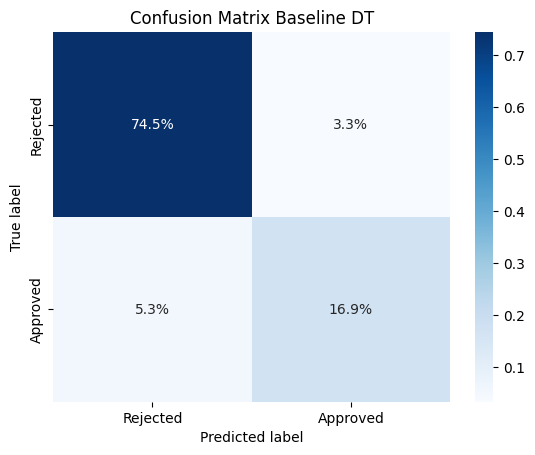

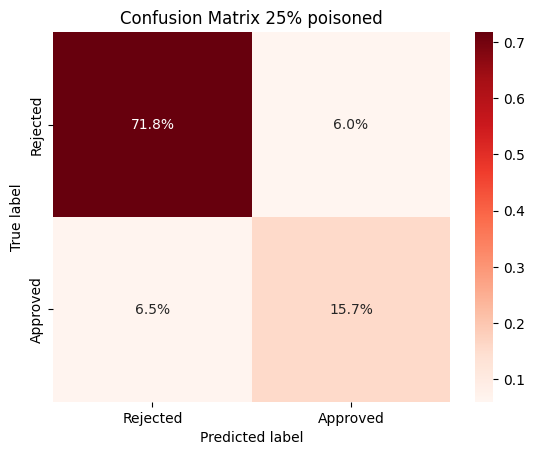

In [36]:
sns.heatmap(cf_norm, annot=labels, fmt='', cmap='Blues', xticklabels=["Rejected", "Approved"], yticklabels=["Rejected", "Approved"])
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix Baseline DT")
plt.show()

#  confusion matrix for flip rate 25%
cm_poisoned = confusion_matrix(y_test, y_pred_poison)
cm_percent = cm_poisoned / cm_poisoned.sum() * 100  # Convert to percent of all samples

cf_norm_poisoned = cm_poisoned.astype('float') / cm_poisoned.sum()

# 2. Create annotation text with '%'
labels_poisoned = (np.asarray(["{0:.1f}%".format(value*100) 
                    for value in cf_norm_poisoned.flatten()])).reshape(2,2)

# 3. Plot
sns.heatmap(cf_norm_poisoned, annot=labels_poisoned, fmt='', cmap='Reds', xticklabels=["Rejected", "Approved"], yticklabels=["Rejected", "Approved"])
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix 25% poisoned")
plt.show()

# Rocauc after poisoned

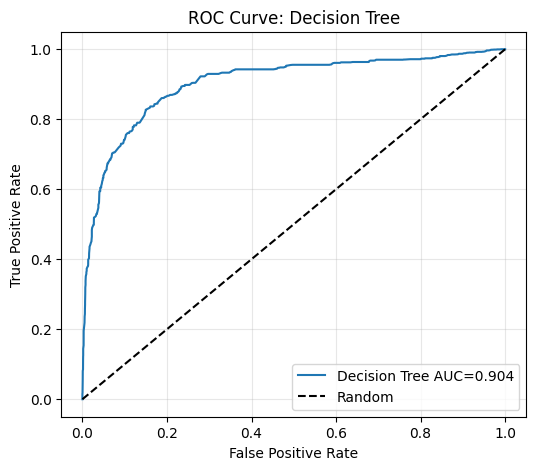

In [37]:
y_proba_poison = dt_poison.predict_proba(X_test)[:, 1]

# 2. Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_proba_poison)
auc = roc_auc_score(y_test, y_proba_poison)

# 3. Plot ROC curve
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"Decision Tree AUC={auc:.3f}")
plt.plot([0,1], [0,1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Decision Tree")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

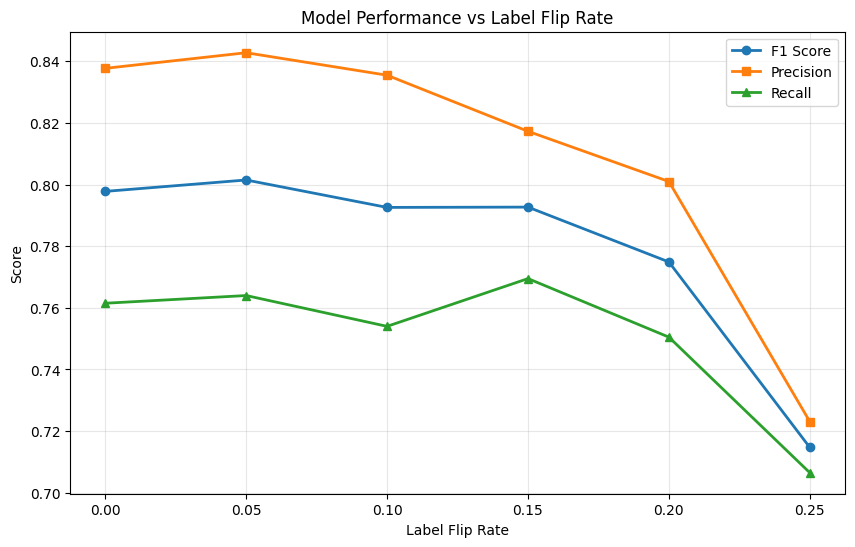

In [38]:
fig, ax = plt.subplots(figsize=(10, 6))
rates_with_baseline = [0] + flip_rates
f1_scores = [real_f1] + [flip_results[r]['f1'] for r in flip_rates]
prec_scores = [real_prec] + [flip_results[r]['precision'] for r in flip_rates]
rec_scores = [real_rec] + [flip_results[r]['recall'] for r in flip_rates]

ax.plot(rates_with_baseline, f1_scores, 'o-', label='F1 Score', linewidth=2)
ax.plot(rates_with_baseline, prec_scores, 's-', label='Precision', linewidth=2)
ax.plot(rates_with_baseline, rec_scores, '^-', label='Recall', linewidth=2)
ax.set_xlabel('Label Flip Rate')
ax.set_ylabel('Score')
ax.set_title('Model Performance vs Label Flip Rate')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

# isolation forest

### tuning


* search grid want scores, iso forest have no scores due to unsuperviced model. but we cna do it cutsom, we calculate the perfomance by checking how many namoalies OUT OF the true flipped anomalies that the isoforest gets, and witht that we have created our own search. it exhausivly searches all combination and updates the "best score " variable.

Notice: the less max_sampes parameter, the more anomalies WITHIN our poisond flipped it finds???
    
    takes 2 min

    in the cell right below this one we show the parameters we have used to get the best Hyperparameters for our model. We have extracted the best parameters from the cell below and added it in the uncommeted cell for faster runtime.

In [39]:
# param_grid2 = {
#     'n_estimators': [150, 200, 250, 300],
#     'max_samples': [20, 30, 40, 50],
#     'contamination': [0.1, 0.15, 0.19, 0.25],
#     'bootstrap' : [False, True],
#     'max_features' : [3, 4, 5, 12]
# }

In [40]:
from itertools import product

param_grid2 = {
    'n_estimators': [200],
    'max_samples': [30],
    'contamination': [0.19],
    'bootstrap' : [False],
    'max_features' : [4]
}

# Get all combinations of parameters
keys, values = zip(*param_grid2.items())
param_combinations = [dict(zip(keys, v)) for v in product(*values)]

best_score = -1
best_params = None
best_anomaly_indices = None
best_detected_poisoned = None

for params in param_combinations:
    # iso_model will change after each iteration.
    iso_model = IsolationForest(**params, random_state=42)
    preds = iso_model.fit_predict(X_train)
    anomaly_indices = set(X_train.index[preds == -1])

    # Calculate overlap with flipped indices
    detected_poisoned = anomaly_indices & set(flipped)
    score = len(detected_poisoned)
    # print(f"Params: {params} | Detected poisoned: {score}")

    # Track the best
    if score > best_score:
        best_score = score
        best_params = params
        best_anomaly_indices = anomaly_indices


# we add this again because we want to use the "best params"
iso_model_tuned = IsolationForest(**best_params, random_state=42)


# below is the values for THE BEST interation that was run above
print("total anomalies detected",len(best_anomaly_indices))
print("\nBest params:", best_params)
print("Max detected poisoned samples:", best_score)


# total anomalies detected 6839

# Best params: {'n_estimators': 200, 'max_samples': 30, 'contamination': 0.19, 'bootstrap': False, 'max_features': 4}
# Max detected poisoned samples: 1750


# med robust scaler:




total anomalies detected 6839

Best params: {'n_estimators': 200, 'max_samples': 30, 'contamination': 0.19, 'bootstrap': False, 'max_features': 4}
Max detected poisoned samples: 1750


# fit the model

In [41]:
print(best_params)
iso_model_tuned.fit(X_train)

{'n_estimators': 200, 'max_samples': 30, 'contamination': 0.19, 'bootstrap': False, 'max_features': 4}


,n_estimators,200
,max_samples,30
,contamination,0.19
,max_features,4
,bootstrap,False
,n_jobs,None
,random_state,42
,verbose,0
,warm_start,False


# tester i confidencen
     dvs genom att printa ut hur confidence den är i sitt val.

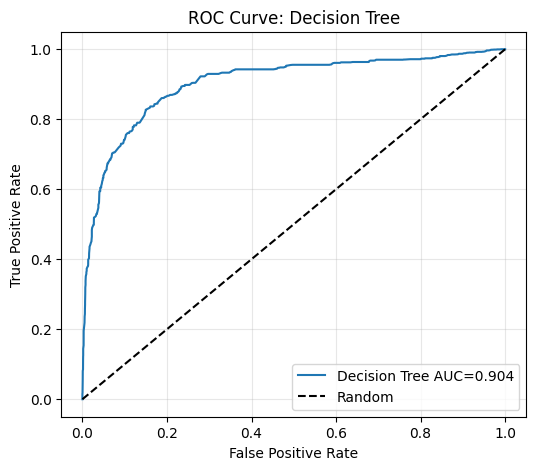

In [42]:
y_proba_poison = dt_poison.predict_proba(X_test)[:, 1]

# 2. Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_proba_poison)
auc = roc_auc_score(y_test, y_proba_poison)

# 3. Plot ROC curve
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"Decision Tree AUC={auc:.3f}")
plt.plot([0,1], [0,1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Decision Tree")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# confusuion matrix ISO forest

# confidence ISo forest
    we need to check how confidence out isomodel is to the 1700 samples it has said is anomalie. 

# evaluation with rocauc
    jätte bad roc auc score FFS. betyder att vår model har 50/50 chans att hitta poisoned samples. pga lable flipping.

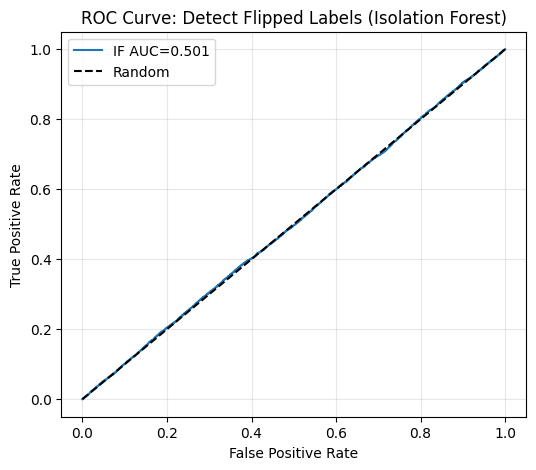

In [43]:
# to make malignant as ones

# Ground truth: 1 for poisoned (flipped), 0 for normal
y_true_anom = X_train.index.isin(flipped).astype(int)

# Get anomaly scores (we use decision_function to get the true anomaly values from Isolation forest)
anomaly_score = iso_model_tuned.decision_function(X_train)

# ROC curve and AUC
fpr, tpr, _ = roc_curve(y_true_anom, -anomaly_score)  
auc = roc_auc_score(y_true_anom, -anomaly_score)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"IF AUC={auc:.3f}")
plt.plot([0,1], [0,1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Detect Flipped Labels (Isolation Forest)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# checking path lenght
    * sisolation forest outputs a score that is derived from the expected path lenght of each test instance E(h(x))
    * we check the expected path lenght and compare it to an anomalies pathlengt, this will give us a picture of how close each anomalie are to non anomalies

    * more negative score correlates with more likely an anomaly sample.

    * results:
        - If E(h(x)) > 0 then normal 
        - If E(h(x)) < 0 then anomaly


In [ ]:
# checking path length

iso_predictions = iso_model_tuned.predict(X_train)
iso_scores = iso_model_tuned.decision_function(X_train)


anomalies = np.where(iso_predictions == -1)
normals = np.where(iso_predictions == 1)

anomaly_index = anomalies[0][4]
normal_index = normals[0][2]

# print(anomaly_index)
# print(normal_index)

# Get the score for the anomalous sample
anomaly_score = iso_scores[anomaly_index]
    
# Get the score for the normal sample
normal_score = iso_scores[normal_index]

print(f"Sample at index {anomaly_index} is an ANOMALY with a score of: {anomaly_score:.4f}")
print(f"Sample at index {normal_index} is NORMAL with a score of:    {normal_score:.4f}")

Sample at index 46 is an ANOMALY with a score of: -0.0146
Sample at index 2 is NORMAL with a score of:    0.0187


    min and max scores in the list of anomalies. shows that most predictions are close to 0
    

In [45]:
print(iso_scores.min())
print(iso_scores.max())


-0.11931953968134579
0.09456069459831573


# SHAP
    understadning the feature contrifbutuon
    
    

# trying own build samples
    trying to understand what features that are important for isolation forest when prediktion.
    we notice that isolation forest and DEsision tre DOES NOT have the same importance in features.

In [ ]:
# # Create a sample with mean values of each feature

# # ändra samples beroende på vad SHAP säger om varför ISO forest sääger
# # nej till lone eller inte, ändra dom värden och se om det påvärkar mycket
# # Desisiton tree säger att previous_loan_defaults_on_file påvärkar 
# # jättemycket, men ISO forest bryr sig inte om den
# sample = {
#     "person_age": 10.752,
#     "person_education": 1.742415,
#     "person_income": 100.354051,
#     "person_emp_exp": 0.402534,
#     "person_home_ownership": 1.694043,
#     "loan_amnt": 9569.354023,
#     "loan_intent": 2.531285,
#     "loan_int_rate": 11.005086,
#     "loan_percent_income": 0.139420,
#     "cb_person_cred_hist_length": 5.871888,
#     "credit_score": 100.592937,
#     "previous_loan_defaults_on_file": 1 #0.508085
# }

# sample = pd.DataFrame([sample], columns=X_train.columns)
# # Predict with the trained Isolation Forest
# result = iso_model_tuned.predict(sample)

# print("Prediction (1 = normal, -1 = anomaly):", result[0])

# NOTE TILL 24 MARS

    allt ovan kod ska vara klar

    här slutade du. gör shap values. två olika plotts. en med punkter och en med waterfall plott. titta analyzera

# SHAP BELOW 
    we use the same indexes and values as above cells. index 42 and 2. for consistancy.

Row position: 46
Prediction: ANOMALY (-1)
Decision score f(x): -0.0146
Check: base + sum(shap) = f(x)
  0.0254 + -0.0400 = -0.0146


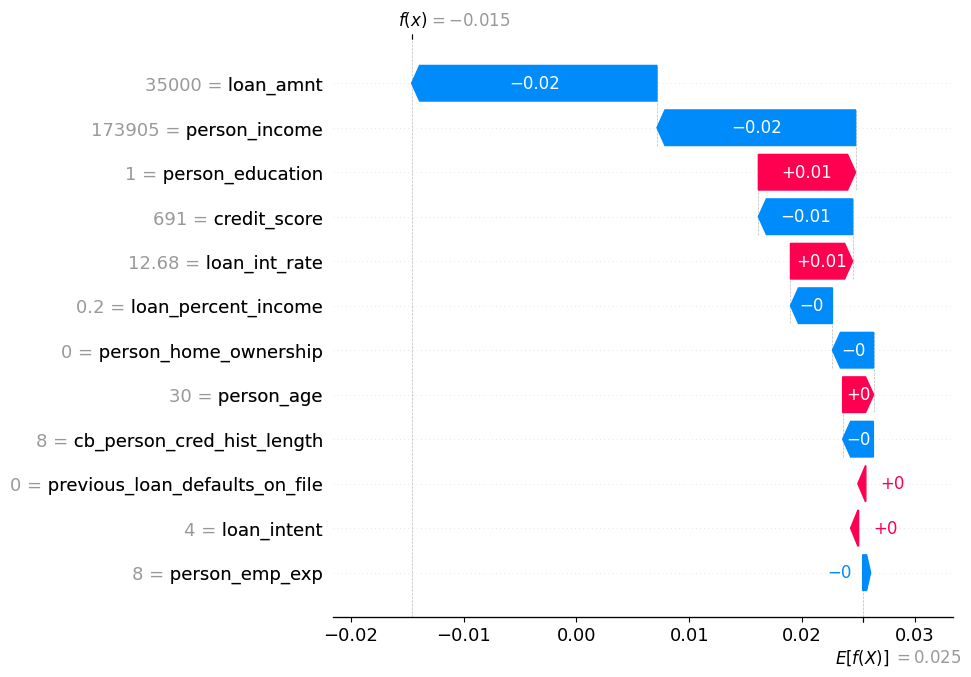

Row position: 46
Prediction: NORMAL (1)
Decision score f(x): 0.0187
Check: base + sum(shap) = f(x)
  0.0254 + -0.0066 = 0.0187


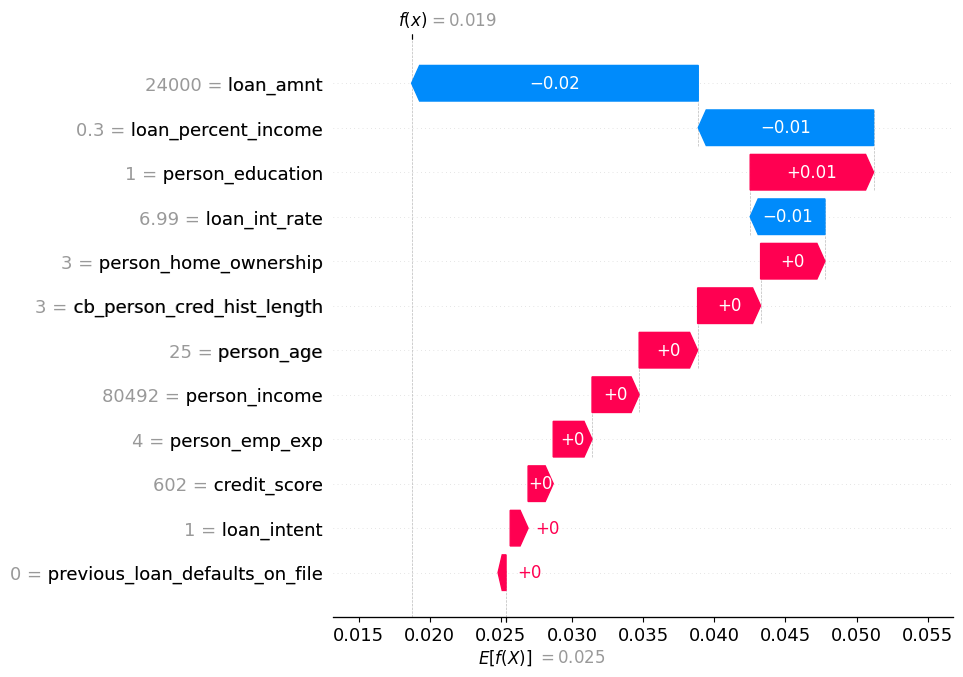

In [ ]:
explainer_iso = shap.Explainer(iso_model_tuned.decision_function, X_train)

# anomaly_index, normal_index - can be changed 2 cells above.
# creating new dataset for only the two samples
two_samples = X_train.iloc[[anomaly_index, normal_index]]

# get class labels (-1/1) and true scores ([1,-1]) for those exact rows.
pred_two = iso_model_tuned.predict(two_samples)
score_two = iso_model_tuned.decision_function(two_samples)

# SHAP values for same rows
shap_two = explainer_iso(two_samples)

label_map = {-1: "ANOMALY", 1: "NORMAL"}

for i, idx in enumerate([anomaly_index, anomaly_index]):
    print(f"Row position: {idx}")
    print(f"Prediction: {label_map[pred_two[i]]} ({pred_two[i]})")
    print(f"Decision score f(x): {score_two[i]:.4f}")
    print("Check: base + sum(shap) = f(x)")
    print(f"  {shap_two[i].base_values:.4f} + {shap_two[i].values.sum():.4f} = "
          f"{(shap_two[i].base_values + shap_two[i].values.sum()):.4f}")

    shap.plots.waterfall(shap_two[i], max_display=12)

In [52]:
# # Get anomaly scores for all training samples

# # Find index of sample closest to 0.1
# idx_pos = np.argmin(np.abs(iso_scores - 0.1))
# print(f"Sample closest to f(x)=0.1: index {idx_pos}, score {iso_scores[idx_pos]:.4f}")

# # Find index of sample closest to -0.1
# idx_neg = np.argmin(np.abs(iso_scores + 0.1))
# print(f"Sample closest to f(x)=-0.1: index {idx_neg}, score {iso_scores[idx_neg]:.4f}")

# # Optionally, show the feature values for these samples
# print("Sample (f(x)~0.1):")
# print(X_train.iloc[idx_pos])
# print("\nSample (f(x)~-0.1):")
# print(X_train.iloc[idx_neg])

In [ ]:
# # Create a SHAP explainer for the Isolation Forest model

# explainer_iso = shap.Explainer(iso_model_tuned.decision_function, X_train)
# # 



In [ ]:
# # Assuming you already have:
# # scores = iso_model_tuned.decision_function(X_train)
# # idx_pos = np.argmin(np.abs(scores - 0.1))
# # idx_neg = np.argmin(np.abs(scores + 0.1))
# # 
# # Calculate SHAP values for these samples
# shap_values_pos = explainer_iso(X_train.iloc[[idx_pos]])
# shap_values_neg = explainer_iso(X_train.iloc[[idx_neg]])

# print(f"SHAP Waterfall Plot for sample with f(x)~0.1 (index {idx_pos}, score {scores[idx_pos]:.4f}):")
# shap.waterfall_plot(shap_values_pos[0])

# print(f"SHAP Waterfall Plot for sample with f(x)~-0.1 (index {idx_neg}, score {scores[idx_neg]:.4f}):")
# shap.waterfall_plot(shap_values_neg[0])

In [ ]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# # person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
# # --- You can change the features for the x and y axes here ---
# x_feature = 'person_income'
# y_feature = 'loan_amnt'
# # ---------------------------------------------------------

# # Take a random subsample of 1000 from the main dataframe
# df_sample = df_numerical.sample(n=1000, random_state=42)

# # Create the scatter plot
# plt.figure(figsize=(10, 6))
# sns.scatterplot(data=df_sample, x=x_feature, y=y_feature, hue='loan_status', palette='viridis', alpha=0.7)

# # Add titles and labels for clarity
# plt.title(f'Scatter Plot of {y_feature} vs. {x_feature}')
# plt.xlabel(x_feature)
# plt.ylabel(y_feature)
# plt.legend(title='Loan Status (0=Rejected, 1=Approved)')
# plt.grid(True, alpha=0.3)
# plt.show()

# Obesevation 
    intresting that person age can contribute 

# removing features
    features with correlations can make the SHAP values confused. why? i explain
    vi ska ta bort de mest correlation features. t.ex person age och emp_exp_age. då tar vi bort person age för att det är det som spelar minst roll kanske. 
    
    sen gör du isolation forest igen, kanske till och med dt tree bara för att se hur dålig / bra den blev, sen skriver du att du bara gör en mindre chek inte full check med alla metrics osv. 